# Example of using fuctions from package tools

Set up the path for the execution.

In [1]:
import sys
import os
import pandas as pd
from emtk import parsers, visualization, util, aoi
from tools import path_similarity, auxiliary, image_generation, setup_paths

paths = setup_paths()
lib_path = paths['lib_path']

Set the experiment_id and trial_id we want to study.

In [2]:
sample_size = 8

Parse the data.

In [3]:
# Parse EMIP data
os.chdir(lib_path)
eye_events, samples = parsers.EMIP(sample_size)

Please cite this paper:  https://dl.acm.org/doi/abs/10.1145/3448018.3457425
parsing file: 100_rawdata.tsv
parsing file: 101_rawdata.tsv
parsing file: 102_rawdata.tsv
parsing file: 103_rawdata.tsv
parsing file: 104_rawdata.tsv
parsing file: 105_rawdata.tsv
parsing file: 106_rawdata.tsv
parsing file: 107_rawdata.tsv


Specify the experiment and trial we want to analyze for the scanpath

In [4]:
# exp = ('experiment_id', 'trial_id')
exp_a = ('103', '2')
exp_b = ('104', '2')

Generate image specified experiment and trial.

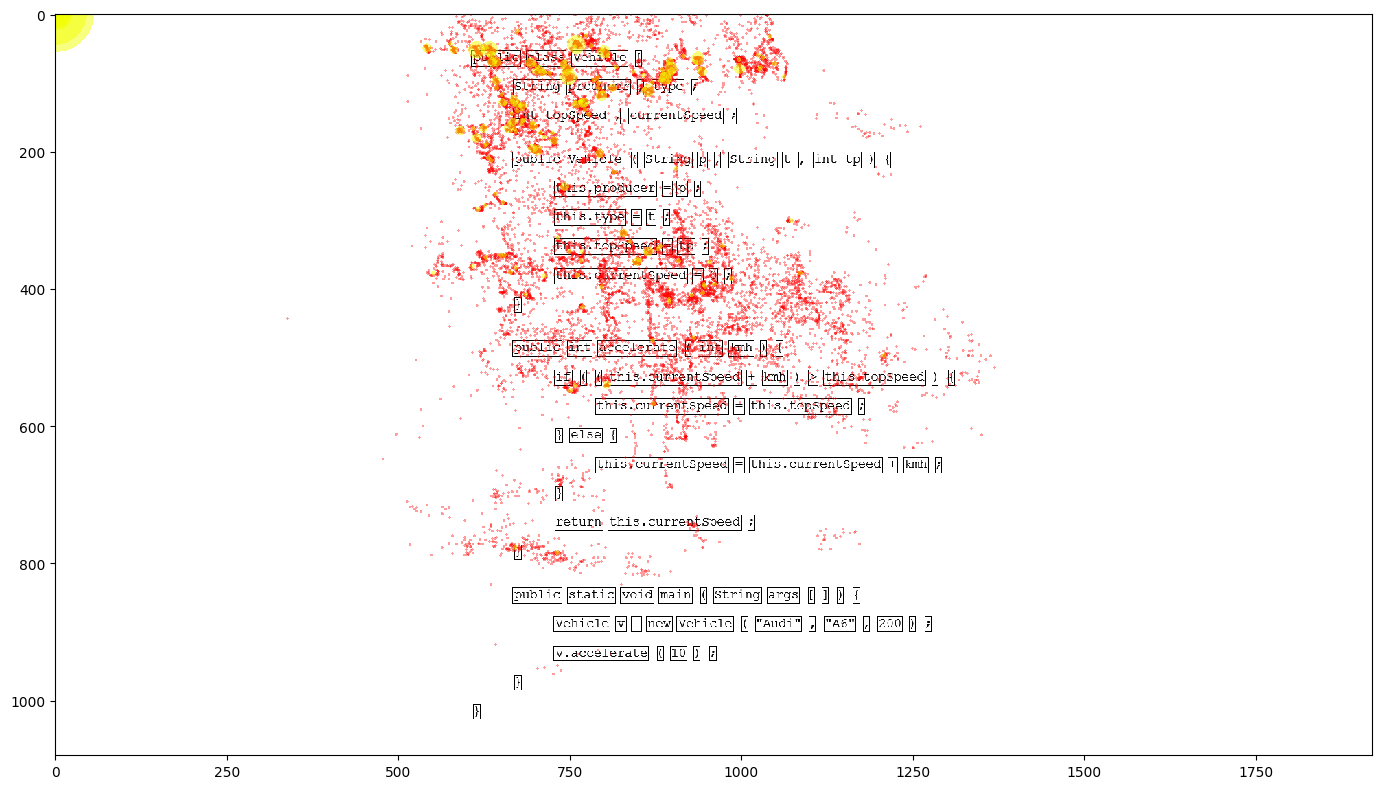

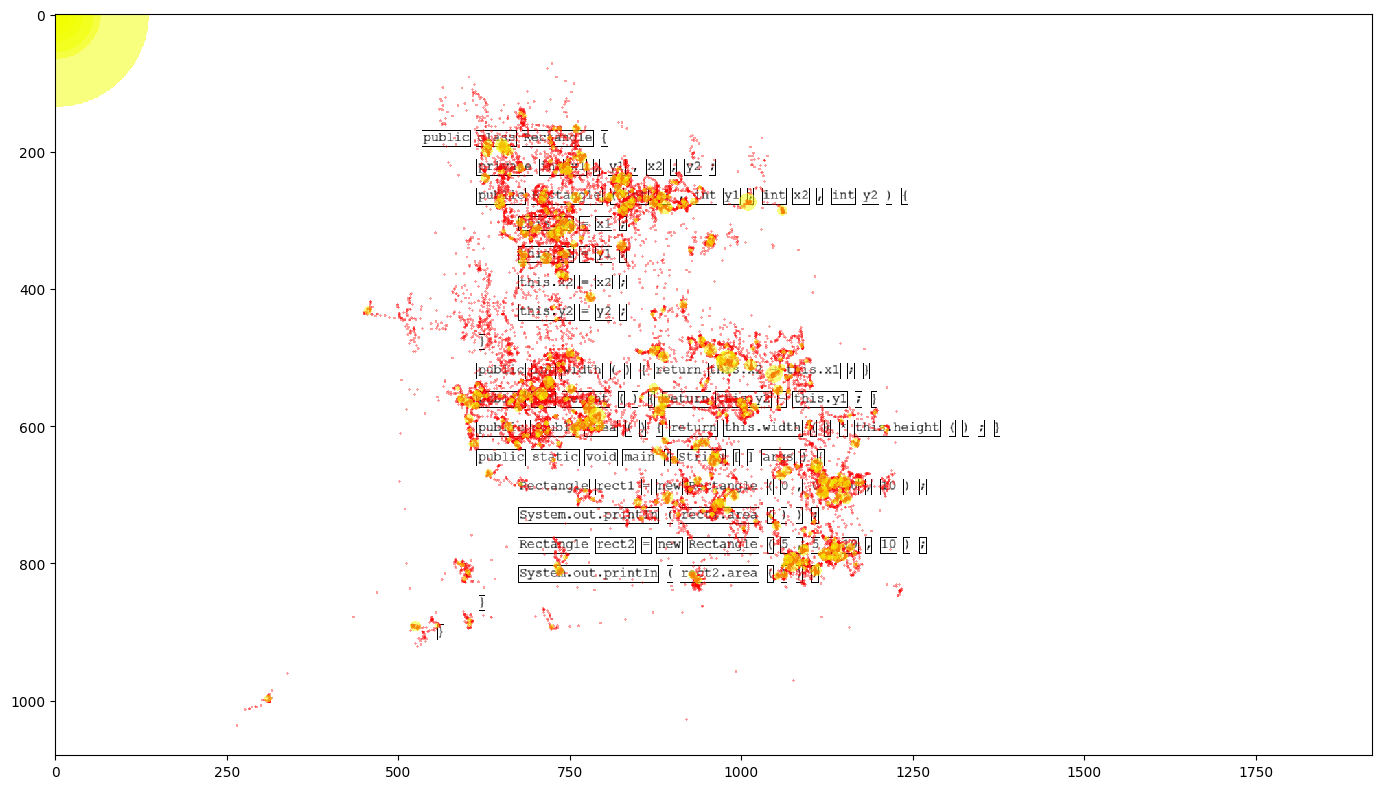

In [5]:
# possible options for image_type are "heatmap", "fixation_duration", "fixation_timeline", "all"
# when query is set to True, the experiment_id will be determined by the query

image_generation.emip_gen(exp = exp_a, eye_events = eye_events, samples = samples, query = False, image_type = 'all')

image_generation.emip_gen(exp = exp_b, eye_events = eye_events, samples = samples, query = True, image_type = 'all')

Use the python library multimatch_gaze to compute path similarity.\
We use 2 random generated scan-path as baseline to normalize the final value.\ 

final_value = original_value - base_line.

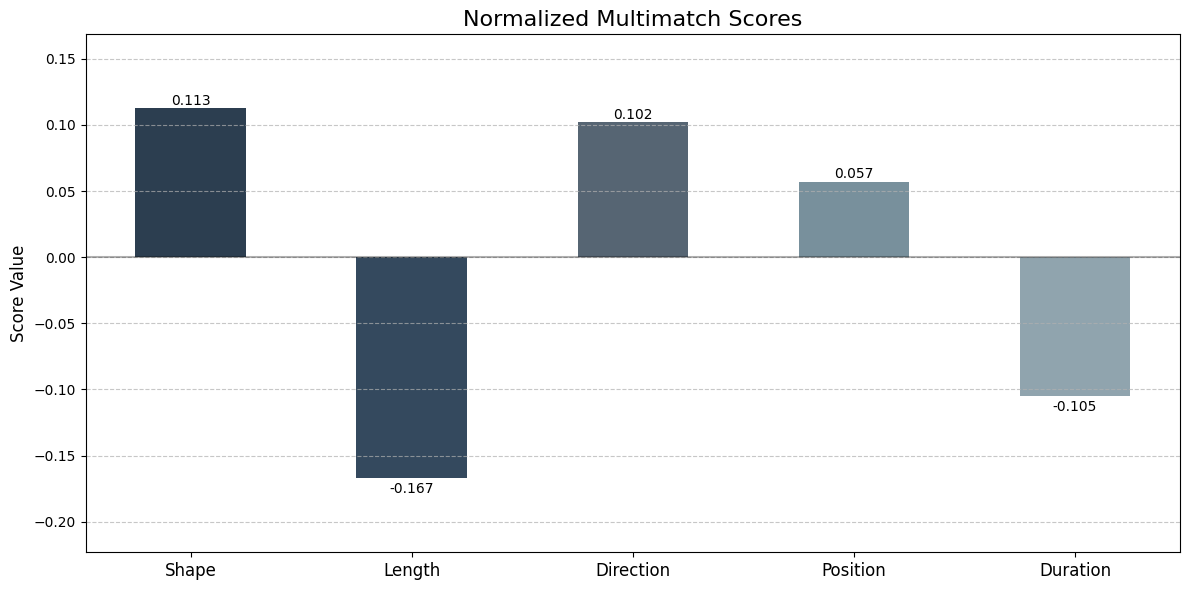

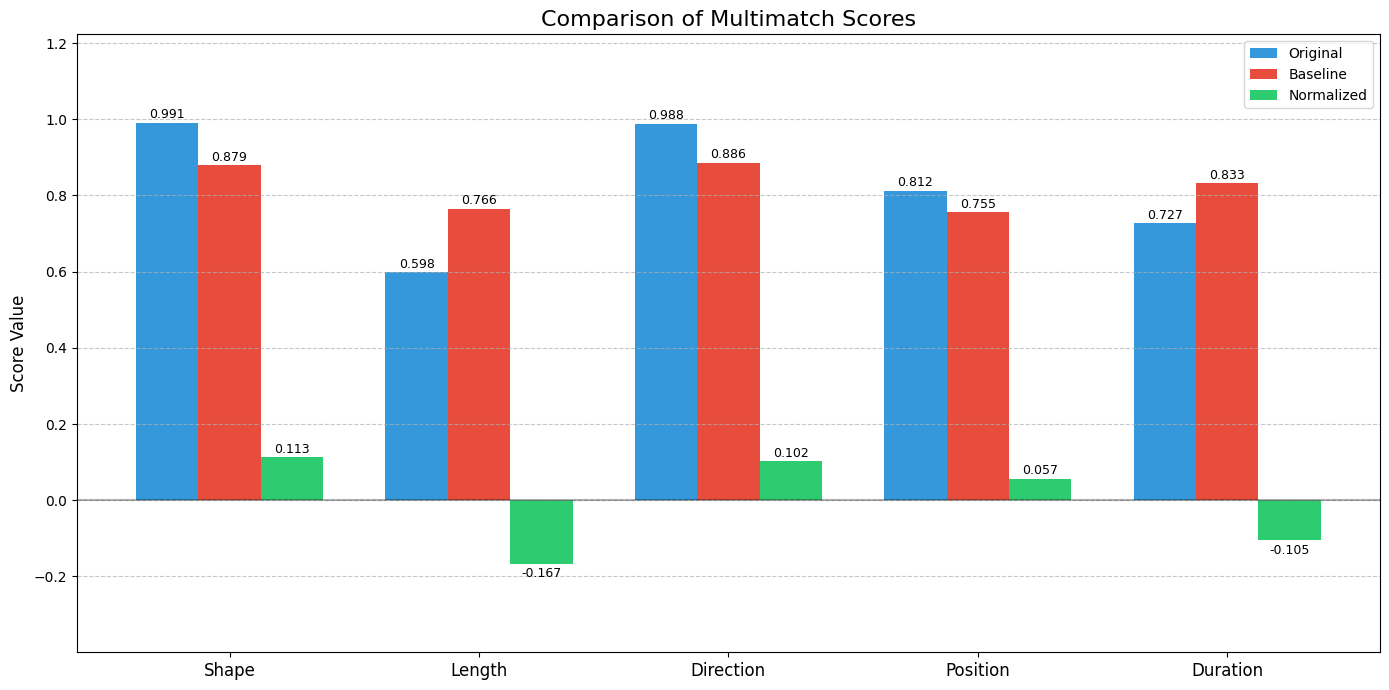

In [6]:
import matplotlib.pyplot as plt

scores = path_similarity.multimatch(
    exp_a=exp_a,
    exp_b=exp_b,
    eye_events=eye_events,
    data_set='original'
)

auxiliary.visualize_multimatch_scores(scores, "Normalized Multimatch Scores")
plt.show()

auxiliary.visualize_all_scores(scores)
plt.show()

Compute path similarity by using scasim (part of ScanDL)

In [7]:
# parameter normalize can be 'durations', 'fixations' or 'None'
# It actually compute Scan path difference
scores = path_similarity.scasim(
    exp_a=exp_a,
    exp_b=exp_b,
    eye_events=eye_events,
    normalize = 'duration',
    data_set = 'original',
)

print("Scasim score:", scores["original_score"])
print("Normalized Scasim score:", scores["final_score"])

Scasim score: 0.8506936803968832
Normalized Scasim score: -0.06697768731539044


Compute NLD for both scanpath

In [8]:
# scores = path_similarity.nld(exp_a, exp_b, eye_events, data_set="original")

# print(f"Distance: {scores['original_distance']}, NLD: {scores['original_nld']}")
# print(f"Normalized: Distance: {scores['final_distance']}, NLD: {scores['final_nld']}")

# Use corrected EMIP dataset

In [9]:
from tools import auxiliary, path_similarity

eye_events = auxiliary.parse_corrected_emip_data()
allowed_experiments = eye_events['experiment_id'].dropna().unique()

# exp = ('experiment_id', 'trial_id')
exp_a = ('135', '2')
exp_b = ('145', '2')

if exp_a[0] not in allowed_experiments:
    print(f"Experiment {exp_a[0]} is not allowed.")
    raise SystemExit("Not allowed experiment id")

if exp_b[0] not in allowed_experiments:
    print(f"Experiment {exp_b[0]} is not allowed.")
    raise SystemExit("Not allowed experiment id")

Processing data for 159 participants...


Processing data for 159 participants...


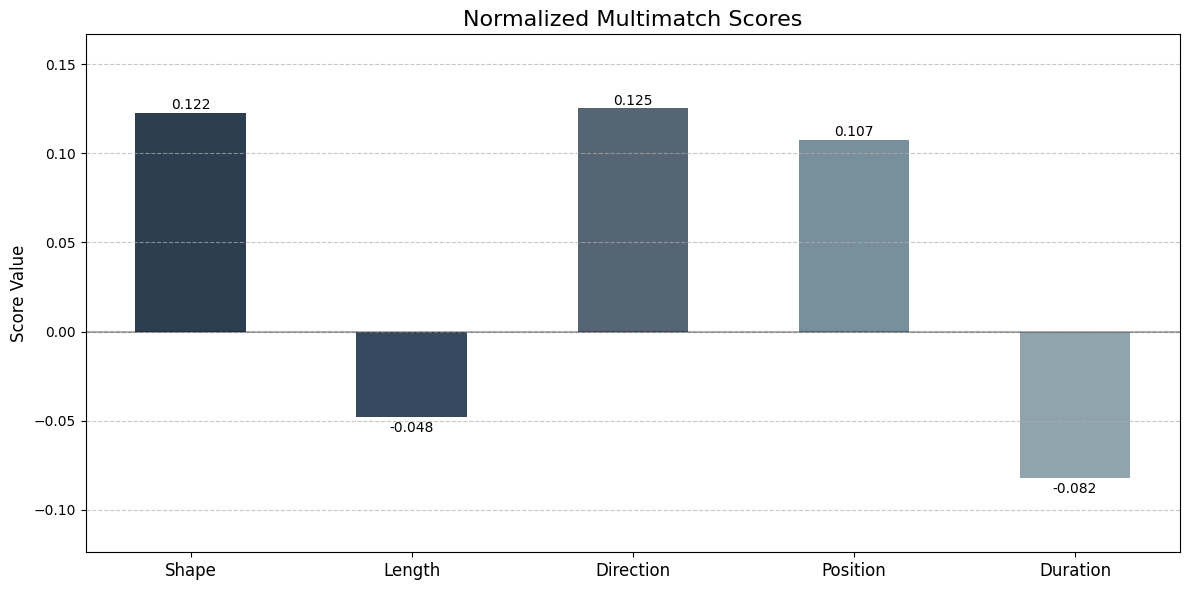

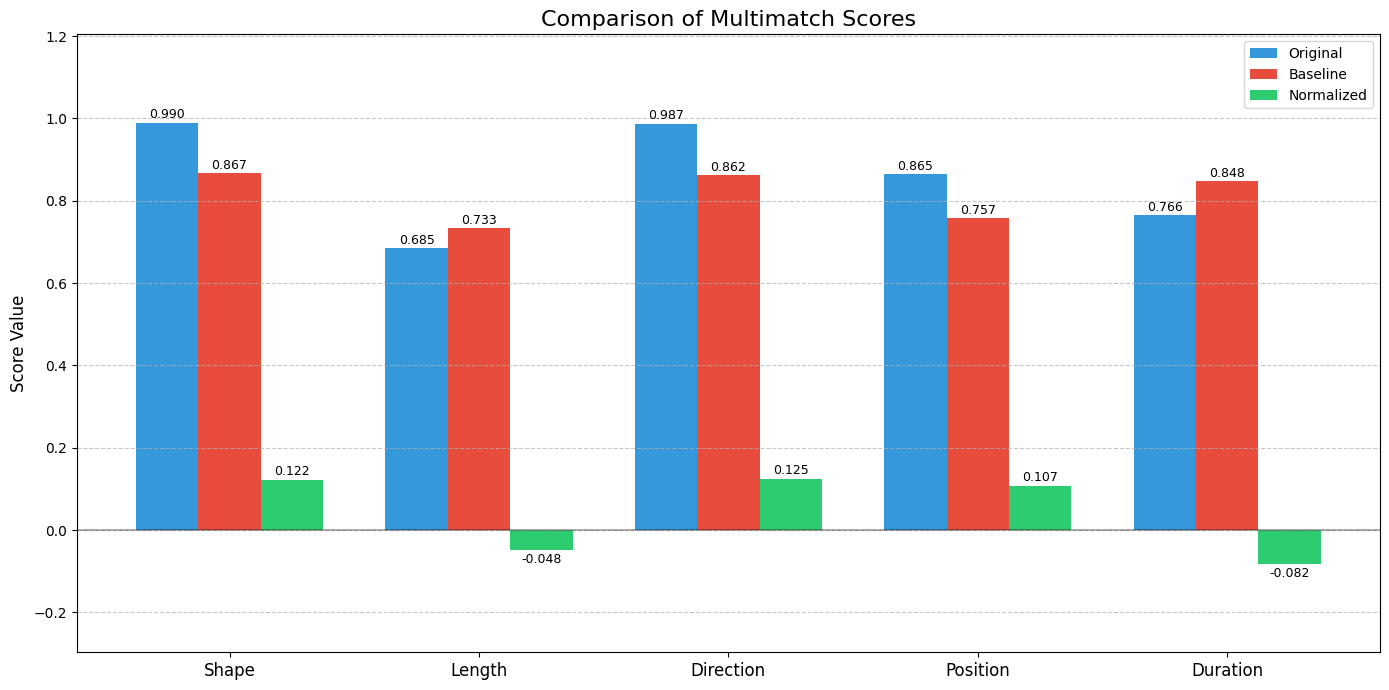

In [10]:
import matplotlib.pyplot as plt

scores = path_similarity.multimatch(
    exp_a=exp_a,
    exp_b=exp_b,
    eye_events=eye_events,
    data_set='corrected'
)

auxiliary.visualize_multimatch_scores(scores, "Normalized Multimatch Scores")
plt.show()

auxiliary.visualize_all_scores(scores)
plt.show()

In [11]:
scores = path_similarity.scasim(
    exp_a=exp_a,
    exp_b=exp_b,
    eye_events=eye_events,
    normalize = 'duration',
    data_set = 'corrected',
)

print("Scasim score:", scores["original_score"])
print("Normalized Scasim score:", scores["final_score"])

Processing data for 159 participants...
Scasim score: 0.8295406462753452
Normalized Scasim score: -0.09366173689238577


In [12]:
# scores = path_similarity.nld(exp_a, exp_b, eye_events, data_set="corrected")

# print(f"Distance: {scores['original_distance']}, NLD: {scores['original_nld']}")
# print(f"Normalized: Distance: {scores['final_distance']}, NLD: {scores['final_nld']}")